# Full Pipeline Demo

This notebook runs the full OSOS pipeline using local data.

## 1. Imports and environment

In [18]:
import subprocess
import os
import glob

# Ensure Hugging Face uses a project-local cache directory
os.environ.setdefault("HF_HOME", os.path.join("Modules", "OSOS", "model_cache"))
os.environ.setdefault("TRANSFORMERS_CACHE", os.path.join("Modules", "OSOS", "model_cache"))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from transformers import pipeline

## 2. Paths

In [19]:

base_path = "../data"
cache_dir = os.path.join("Modules", "OSOS", "model_cache")
os.makedirs(cache_dir, exist_ok=True)

## 3. Scraping disabled (offline data only)

In [20]:
# Part 1 (scraping) is disabled because data was downloaded offline
# using Modules/OSOS/task1_download.py.

## 4. Prepare / load data

In [21]:
intermediate_file = "Scrap_Results_bursty.csv"

print("Part 2: Performing binary classification on the scrapped and pre-processed data")
print("Part 2a: Preparing data for classification")

filepath = os.path.join(base_path, intermediate_file)
use_prepare_data = False
openai_command = f"openai tools fine_tunes.prepare_data -f {filepath}"

base_filename = intermediate_file.replace(".csv", "")

if use_prepare_data:
    prepared_patterns = [os.path.join(base_path, f"{base_filename}_prepared*.jsonl")]
    for pattern in prepared_patterns:
        for path in glob.glob(pattern):
            try:
                os.remove(path)
            except OSError:
                pass

    try:
        subprocess.check_call(openai_command, shell=True)
        print("Command executed successfully.")
    except subprocess.CalledProcessError as e:
        print("Command execution failed: %s", e)
        raise

    jsonl_filename = base_filename + "_prepared_train.jsonl"
    json_filepath = os.path.join(base_path, jsonl_filename)
    if not os.path.exists(json_filepath):
        jsonl_filename = base_filename + "_prepared.jsonl"
        json_filepath = os.path.join(base_path, jsonl_filename)

    data1 = pd.read_csv(filepath)
    data2 = pd.read_json(json_filepath, lines=True)
    combined_df = data2[['prompt', 'completion']].join(data1['date'])
else:
    data1 = pd.read_csv(filepath)
    if 'completion' not in data1.columns:
        data1['completion'] = 'neutral'
    data1['prompt'] = data1['tweet'].astype(str)
    combined_df = data1[['prompt', 'completion', 'date']]

display(combined_df.head())

Part 2: Performing binary classification on the scrapped and pre-processed data
Part 2a: Preparing data for classification


,prompt,completion,date
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",neutral,2010-02-09
1,is upset that he can't update his Facebook by ...,neutral,2009-09-28
2,@Kenichan I dived many times for the ball. Man...,neutral,2009-08-15
3,my whole body feels itchy and like its on fire,neutral,2009-07-26
4,"@nationwideclass no, it's not behaving at all....",neutral,2010-02-09


## 5. Split into chunks

In [22]:
print("Part 2b: Splitting the data into 4 chunks for faster processing")

num_rows = len(combined_df)
part_size = num_rows // 4

parts = [combined_df[i * part_size:(i + 1) * part_size] for i in range(4)]
part_files = []
for i, part in enumerate(parts):
    jsonl_partfilename = f'{base_filename}_part_{i+1}.jsonl'
    part_filepath = os.path.join(base_path, jsonl_partfilename)
    part_files.append(part_filepath)
    part.to_json(part_filepath, orient='records', lines=True)

print("The 4 chunks are:")
print(part_files)

Part 2b: Splitting the data into 4 chunks for faster processing
The 4 chunks are:
['../data\\Scrap_Results_bursty_part_1.jsonl', '../data\\Scrap_Results_bursty_part_2.jsonl', '../data\\Scrap_Results_bursty_part_3.jsonl', '../data\\Scrap_Results_bursty_part_4.jsonl']


## 6. Zero-shot classification

In [24]:
print("Part 2c: Performing binary classfication on the 4 chunks using a fine-tuned model")

zero_shot = pipeline(
    "zero-shot-classification",
    model="valhalla/distilbart-mnli-12-1",
)
candidate_labels = ["informative", "not_informative"]

total_rows = sum(len(pd.read_json(f, lines=True)) for f in part_files)
processed_rows = 0
print(f"Total tweets to label: {total_rows}")

for file in part_files:
    test = pd.read_json(file, lines=True)

    responses = []
    for i, prompt in enumerate(test['prompt'], start=1):
        tweet_text = prompt.replace(" ->", "")
        result = zero_shot(tweet_text, candidate_labels)
        response = result["labels"][0]

        responses.append(response)
        processed_rows += 1
        if processed_rows % 100 == 0 or processed_rows == total_rows:
            print(f"Labeled {processed_rows}/{total_rows}")

    test['response'] = responses
    test.to_json(file, orient='records', lines=True)

Part 2c: Performing binary classfication on the 4 chunks using a fine-tuned model


c:\Users\K.Shokraneh\Projs\NLP\Crisis-Prediction\.venv\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Total tweets to label: 1444
Labeled 100/1444
Labeled 200/1444
Labeled 300/1444
Labeled 400/1444
Labeled 500/1444
Labeled 600/1444
Labeled 700/1444
Labeled 800/1444
Labeled 900/1444
Labeled 1000/1444
Labeled 1100/1444
Labeled 1200/1444
Labeled 1300/1444
Labeled 1400/1444
Labeled 1444/1444


## 7. Merge results

In [25]:
merged_data = pd.DataFrame()

print("Part 2d: Merging the classified dataframes into one")
for file_name in part_files:
    data = pd.read_json(file_name, lines=True)
    merged_data = merged_data.append(data, ignore_index=True)

new_file = base_filename + "_final.jsonl"
new_file_csv = base_filename + "_final.csv"
merged_data.to_json(new_file, orient='records', lines=True)

data = pd.read_json(new_file, lines=True)
data = data.drop('completion', axis=1)

print("Binary Classification completed successfully")
display(data.head())

Part 2d: Merging the classified dataframes into one
Binary Classification completed successfully


C:\Users\K.Shokraneh\AppData\Local\Temp\ipykernel_10816\2792511269.py:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_data = merged_data.append(data, ignore_index=True)
C:\Users\K.Shokraneh\AppData\Local\Temp\ipykernel_10816\2792511269.py:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_data = merged_data.append(data, ignore_index=True)
C:\Users\K.Shokraneh\AppData\Local\Temp\ipykernel_10816\2792511269.py:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_data = merged_data.append(data, ignore_index=True)
C:\Users\K.Shokraneh\AppData\Local\Temp\ipykernel_10816\2792511269.py:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat inste

,prompt,date,response
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",2010-02-09,not_informative
1,is upset that he can't update his Facebook by ...,2009-09-28,not_informative
2,@Kenichan I dived many times for the ball. Man...,2009-08-15,informative
3,my whole body feels itchy and like its on fire,2009-07-26,not_informative
4,"@nationwideclass no, it's not behaving at all....",2010-02-09,not_informative


## 8. Sentiment analysis

In [27]:
print("Part 3: Performing sentiment analysis on the tweets")

# sentiment = pipeline(
#     "sentiment-analysis",
#     model="typeform/distilbert-base-uncased-mnli",
# )

# def sentiment_analysis(classifier, tweets, text_col="prompt"):
#     tweets['sentiment'] = tweets[text_col].apply(lambda x: classifier(str(x))[0]['label'])
#     return tweets

# data = sentiment_analysis(sentiment, data)
# data_filtered = data[data['sentiment'].isin(['CONTRADICTION', 'NEUTRAL'])]
data_filtered = data

print("Sentiment Analysis completed successfully")

Part 3: Performing sentiment analysis on the tweets
Sentiment Analysis completed successfully


## 9. Burst detection + plots

Part 4: Checking for bursts and analysing the data trend
Daily bursts detected: 17
Monthly bursts detected: 3


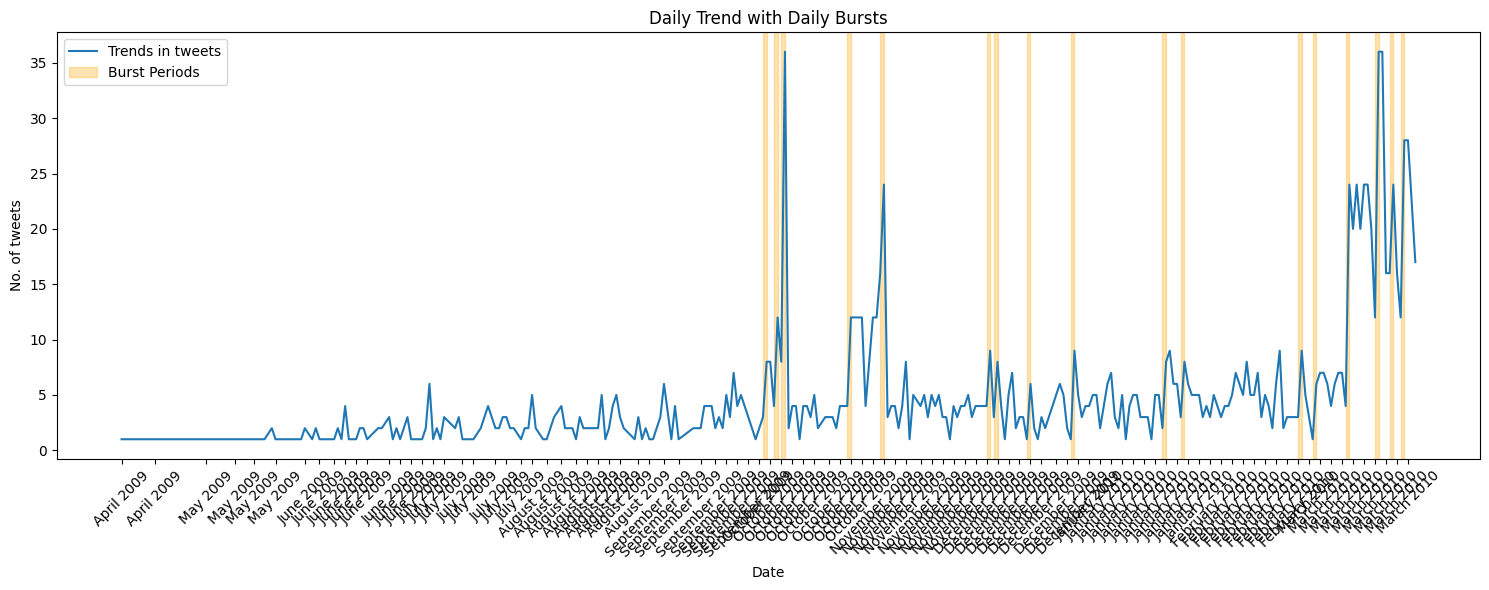

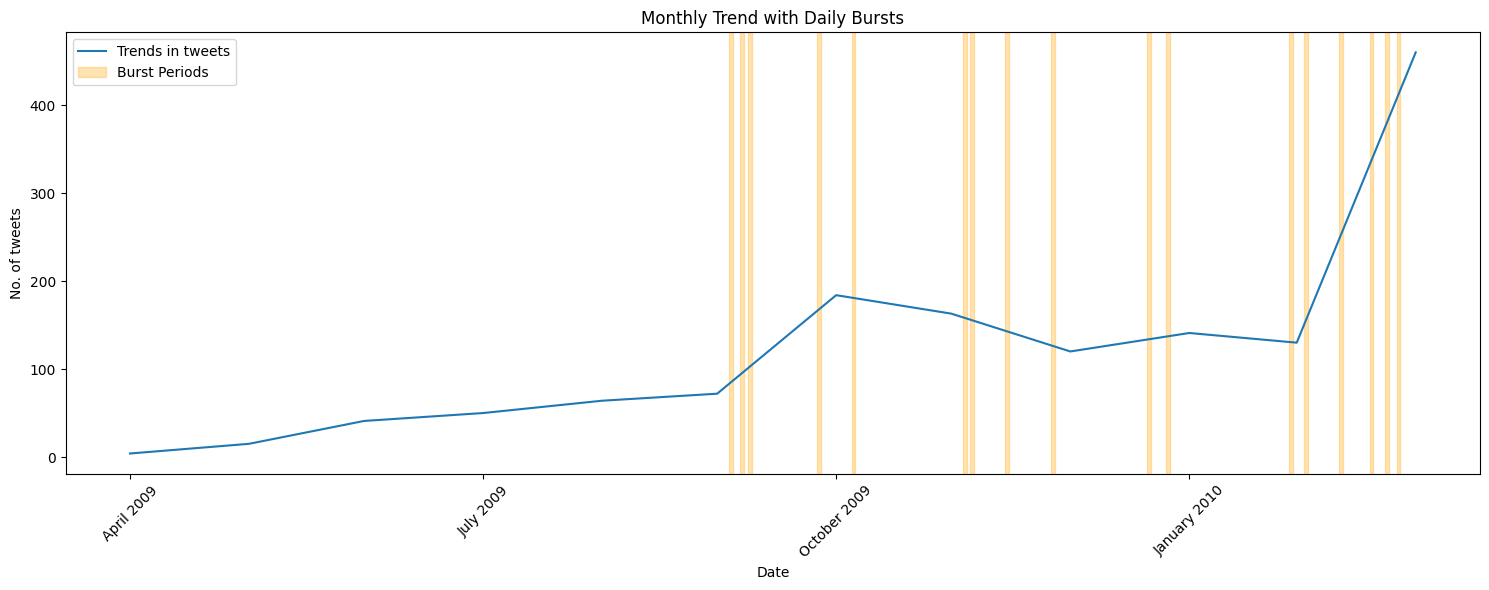

In [44]:
print("Part 4: Checking for bursts and analysing the data trend")

inf_data = data_filtered

def burst_detection(data, threshold, min_length, freq="D"):
    df = data.copy()
    df['date'] = pd.to_datetime(df['date'])
    tweet_count_by_period = df.groupby(df['date'].dt.to_period(freq))['prompt'].count()
    tweet_count_by_period.index = tweet_count_by_period.index.to_timestamp()

    trend_change = tweet_count_by_period.diff().fillna(0)

    burst_indices = []
    burst_start = None
    burst_diff = []

    for index, diff_value in enumerate(trend_change):
        if diff_value > threshold:
            if burst_start is None:
                burst_start = index - 1
        else:
            if burst_start is not None:
                if index - burst_start >= min_length:
                    burst_indices.append((tweet_count_by_period.index[burst_start],
                                          tweet_count_by_period.index[index - 1]))
                    start_value = tweet_count_by_period.iloc[burst_start]
                    end_value = tweet_count_by_period.iloc[index - 1]
                    diff_value = end_value - start_value
                    burst_diff.append(diff_value)

                elif index - burst_start == 1:
                    burst_indices.append((tweet_count_by_period.index[burst_start],
                                          tweet_count_by_period.index[burst_start]))
                    start_value = tweet_count_by_period.iloc[burst_start]
                    end_value = tweet_count_by_period.iloc[index - 1]
                    diff_value = end_value - start_value
                    burst_diff.append(diff_value)
                burst_start = None

    if burst_start is not None and len(trend_change) - burst_start >= min_length:
        burst_indices.append((tweet_count_by_period.index[burst_start],
                              tweet_count_by_period.index[len(trend_change) - 1]))
        start_value = tweet_count_by_period.iloc[burst_start]
        end_value = tweet_count_by_period.iloc[len(trend_change) - 1]
        diff_value = end_value - start_value
        burst_diff.append(diff_value)

    elif burst_start is not None and len(trend_change) - burst_start == 1:
        burst_indices.append((tweet_count_by_period.index[burst_start], tweet_count_by_period.index[burst_start]))
        start_value = tweet_count_by_period.iloc[burst_start]
        end_value = tweet_count_by_period.iloc[len(trend_change) - 1]
        diff_value = end_value - start_value
        burst_diff.append(diff_value)

    result = [list(x) for x in zip(burst_indices, burst_diff)]
    return result

bursts_daily = burst_detection(inf_data, 4, 2, freq="D")
bursts_monthly = burst_detection(inf_data, 4, 2, freq="M")
print(f"Daily bursts detected: {len(bursts_daily)}")
print(f"Monthly bursts detected: {len(bursts_monthly)}")

def plot_with_bursts(data, bursts, freq="D", out_path=None, title=None):
    df = data.copy()
    df['date'] = pd.to_datetime(df['date'])
    tweet_count = df.groupby(df['date'].dt.to_period(freq))['prompt'].count()
    tweet_count.index = tweet_count.index.to_timestamp(how="end") if freq == "M" else tweet_count.index.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(15, 6))
    ax1.plot(tweet_count.index, tweet_count.values, label='Trends in tweets', color='tab:blue')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('No. of tweets', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    xticks = tweet_count.index[::3]
    xticklabels = [d.strftime('%B %Y') for d in xticks]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticklabels, rotation=45)

    burst_periods = [x[0] for x in bursts]
    for burst_start, burst_end in burst_periods:
        ax1.axvspan(burst_start, burst_end, color='orange', alpha=0.3)

    ax1.fill_between([], [], color='orange', alpha=0.3, label='Burst Periods')
    ax1.legend(loc='upper left')
    if title:
        ax1.set_title(title)

    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150)
    plt.show()

daily_png = os.path.join(base_path, "burst_plot_daily.png")
monthly_png = os.path.join(base_path, "burst_plot_monthly.png")
monthly_daily_png = os.path.join(base_path, "burst_plot_monthly_with_daily_bursts.png")

plot_with_bursts(inf_data, bursts_daily, freq="D", out_path=daily_png, title="Daily Trend with Daily Bursts")
plot_with_bursts(inf_data, bursts_daily, freq="M", out_path=monthly_daily_png, title="Monthly Trend with Daily Bursts")




## 10. Save burst periods

In [45]:
print("Part 4b: Saving the burst periods to a file")

def save_to_file(series, filename):
    try:
        final_list = [[x[0][0].strftime('%Y-%m-%d'), x[0][1].strftime('%Y-%m-%d'), x[1]] for x in series]
        burst_df = pd.DataFrame(final_list, columns=['Start', 'End', 'Burst Diff'])
        burst_df.to_csv(filename, index=False)
        return 0
    except Exception as e:
        print(f"An error occurred: {e}")
        return 1

bursts_path = os.path.join(base_path, "bursts_output.csv")
save_to_file(bursts_data, bursts_path)

Part 4b: Saving the burst periods to a file


0